# Backtest 005c — TTM Breakout + Multi-Feature MS Regime Filter

Compare fixed TTM Breakout versions `v1`, `v2`, and `v3` against the same versions gated by the multi-feature Markov-switching regime filter.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
os.environ.setdefault('NUMBA_CACHE_DIR', str(pathlib.Path('.numba_cache').resolve()))
os.environ.setdefault('MPLCONFIGDIR', str(pathlib.Path('.mplconfig').resolve()))
os.environ.setdefault('XDG_CACHE_HOME', str(pathlib.Path('.cache').resolve()))
pathlib.Path(os.environ['NUMBA_CACHE_DIR']).mkdir(parents=True, exist_ok=True)
pathlib.Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
pathlib.Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import talib

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.garch_regime_multifeature import ms_regime_multifeature

plt.style.use('dark_background')
print('imports ok')


imports ok


## 1. Load Data


In [2]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake …')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

# ── extract OHLCV DataFrames (dates × symbols) ────────────────────────────────
open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 197)  |  2016-05-06 00:00:00 → 2026-05-05 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-29,7.31,14.9,23.5,44.0,9.09,12.60,14.50,23.90,5.83,5.63,...,1854.70,60.9,12.60,26.50,3.49,61.4,32.3,21.35,68.0,10.00
2026-05-04,7.48,15.0,23.1,44.0,9.02,12.50,14.55,23.95,5.95,6.02,...,1853.19,60.9,12.55,26.95,3.48,61.3,33.7,21.60,68.0,10.00
2026-05-05,7.37,14.9,22.6,44.8,9.02,12.35,14.40,23.45,5.84,6.27,...,1873.31,61.1,12.45,28.00,3.50,62.5,35.2,21.45,65.9,9.96


## 2. TTM Breakout Helpers


In [3]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────

@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    """Shift a 2-D array along axis 0 (time axis)."""
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    """Count consecutive negative values per column (used for TTM momentum bars)."""
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    """
    Kaufman's Adaptive Moving Average applied column-wise.
    - Efficiency Ratio (ER) = |close - close[period]| / sum(|diff(close)|, period)
    - Smoothing Constant (SC) = (ER * (fast_sc - slow_sc) + slow_sc)^2
    - KAMA[i] = KAMA[i-1] + SC * (close[i] - KAMA[i-1])
    When market is trending (ER -> 1), SC -> fast_sc (tracks quickly).
    When market is choppy   (ER -> 0), SC -> slow_sc (barely moves).
    """
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    """
    Returns a boolean 2-D mask that is True where the KAMA line is
    'flat': |pct change over slope_window bars| < flat_threshold_pct.
    First slope_window rows are always False.
    """
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')


Numba helpers compiled


In [4]:
def compute_signals(
    close, high, low,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout — gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) — NOT gated
      v3 WVF    : volatility spike / contrarian — NOT gated
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # ── indicators → numpy ────────────────────────────────────────────────────
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period,
        mult=bb_multiplier,
        bbl=bb_window,
        lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    # ── KAMA flat-slope mask (computed once, reused across versions) ───────────
    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)  # all True → no filtering

    # ── v1: squeeze no-fire + positive momentum → full KAMA gate ──────────────
    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    # ── v2: momentum just crossed above 0 → full KAMA gate ────────────────────
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    # ── v3: entry_1 (breakout) gated; entry_2 + WVF (bottom fishing) free ─────
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)

        # breakout on squeeze release — only when KAMA is flat
        entry_1 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (ttms_np > 0)
            & flat_np
        )
        # bottom fishing: extended negative momentum — no KAMA filter
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        # WVF: volatility spike / contrarian — no KAMA filter
        entries_np = entry_1 | entry_2 | wvf_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings used as explicit exit signals.
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


## 3. Multi-Feature MS Regime (Regime Source)


In [5]:
MS_WINDOW = 20
MS_PROB_THRESHOLD = 0.5
MS_BENCHMARK_SYMBOL = 'VNINDEX'
FEATURE_NAMES = ['returns', 'spread', 'volume_ratio', 'realized_vol', 'abs_ret_ma', 'benchmark_returns']


def compute_ms_regime(
    open_df: pd.DataFrame,
    high_df: pd.DataFrame,
    low_df: pd.DataFrame,
    close_df: pd.DataFrame,
    vol_df: pd.DataFrame,
    spread_window: int = MS_WINDOW,
    vol_window: int = MS_WINDOW,
    annualize_periods: int = 252,
    benchmark_close: pd.Series | None = None,
) -> dict:
    """Return regime state, probability, and feature tables for all symbols."""
    idx = close_df.index
    regime_map = {}
    regime_prob_map = {}
    feature_maps = {name: {} for name in FEATURE_NAMES}
    benchmark_returns = None
    if benchmark_close is not None:
        benchmark_close = benchmark_close.reindex(idx).ffill().bfill()
        benchmark_log_close = np.log(benchmark_close.astype(float))
        benchmark_returns = benchmark_log_close.diff().fillna(0.0)

    for sym in close_df.columns:
        regime, regime_prob, features = ms_regime_multifeature(
            close_df[sym].to_numpy(dtype=np.float64),
            open_df[sym].to_numpy(dtype=np.float64),
            high_df[sym].to_numpy(dtype=np.float64),
            low_df[sym].to_numpy(dtype=np.float64),
            vol_df[sym].to_numpy(dtype=np.float64),
            benchmark_returns=None if benchmark_returns is None else benchmark_returns.to_numpy(dtype=np.float64),
            spread_window=spread_window,
            vol_window=vol_window,
            annualize_periods=annualize_periods,
        )
        regime_map[sym] = pd.Series(regime, index=idx)
        regime_prob_map[sym] = pd.Series(regime_prob, index=idx)
        for feature_idx, name in enumerate(FEATURE_NAMES):
            feature_maps[name][sym] = pd.Series(features[:, feature_idx], index=idx)

    return {
        'regime': pd.DataFrame(regime_map, index=idx),
        'regime_prob': pd.DataFrame(regime_prob_map, index=idx),
        'features': {
            name: pd.DataFrame(data, index=idx)
            for name, data in feature_maps.items()
        },
    }


def ms_regime_masks(ms: dict, prob_threshold: float = MS_PROB_THRESHOLD) -> tuple:
    """
    Returns (high_stress_df, switch_down_df, switch_up_df) as boolean DataFrames.

    high_stress_df : True when the multi-feature MS model is in regime 1 and
                     the high-stress probability is above prob_threshold.
    switch_down_df : True on the bar that regime leaves the high-stress state.
    switch_up_df   : True on the bar that regime enters the high-stress state.
    """
    high_stress = ((ms['regime'] == 1) & ms['regime_prob'].ge(prob_threshold)).fillna(False)
    prev = high_stress.shift(1).fillna(False)
    switch_down = (~high_stress) & prev
    switch_up = high_stress & (~prev)
    return high_stress, switch_down, switch_up


print('MS regime functions defined')


MS regime functions defined


## 4. Fixed TTM Params per Version


In [6]:
FIXED_TTM_PARAMS = {
    'v1': {
        'bb_window': 15,
        'bb_multiplier': 1.0,
        'bb_matype': 3,
        'kc_window': 38,
        'kc_multiplier': 1.3,
        'kc_atr_period': 5,
        'donichan_window': 9,
        'osc_smoothing_period': 11,
        'atr_period': 6,
        'atr_multiplier': 2.0,
        'low_stop_lookback': 9,
        'consecutive_neg_threshold': 13,
        'william_vix_period': 17,
        'kama_period': 8,
        'kama_fast': 5,
        'kama_slow': 41,
        'kama_slope_win': 5,
        'flat_threshold_pct': 2.7,
    },
    'v2': {
        'bb_window': 15,
        'bb_multiplier': 1.3,
        'bb_matype': 0,
        'kc_window': 52,
        'kc_multiplier': 1.2000000000000002,
        'kc_atr_period': 14,
        'donichan_window': 9,
        'osc_smoothing_period': 13,
        'atr_period': 7,
        'atr_multiplier': 2.6,
        'low_stop_lookback': 3,
        'consecutive_neg_threshold': 8,
        'william_vix_period': 18,
        'kama_period': 11,
        'kama_fast': 2,
        'kama_slow': 36,
        'kama_slope_win': 5,
        'flat_threshold_pct': 2.5,
    },
    'v3': {
        'bb_window': 10,
        'bb_multiplier': 1.2000000000000002,
        'bb_matype': 3,
        'kc_window': 39,
        'kc_multiplier': 1.6,
        'kc_atr_period': 6,
        'donichan_window': 14,
        'osc_smoothing_period': 15,
        'atr_period': 11,
        'atr_multiplier': 2.6,
        'low_stop_lookback': 5,
        'consecutive_neg_threshold': 4,
        'william_vix_period': 17,
        'kama_period': 16,
        'kama_fast': 5,
        'kama_slow': 39,
        'kama_slope_win': 5,
        'flat_threshold_pct': 1.8,
    },
}

for ver, params in FIXED_TTM_PARAMS.items():
    print(ver, params)


v1 {'bb_window': 15, 'bb_multiplier': 1.0, 'bb_matype': 3, 'kc_window': 38, 'kc_multiplier': 1.3, 'kc_atr_period': 5, 'donichan_window': 9, 'osc_smoothing_period': 11, 'atr_period': 6, 'atr_multiplier': 2.0, 'low_stop_lookback': 9, 'consecutive_neg_threshold': 13, 'william_vix_period': 17, 'kama_period': 8, 'kama_fast': 5, 'kama_slow': 41, 'kama_slope_win': 5, 'flat_threshold_pct': 2.7}
v2 {'bb_window': 15, 'bb_multiplier': 1.3, 'bb_matype': 0, 'kc_window': 52, 'kc_multiplier': 1.2000000000000002, 'kc_atr_period': 14, 'donichan_window': 9, 'osc_smoothing_period': 13, 'atr_period': 7, 'atr_multiplier': 2.6, 'low_stop_lookback': 3, 'consecutive_neg_threshold': 8, 'william_vix_period': 18, 'kama_period': 11, 'kama_fast': 2, 'kama_slow': 36, 'kama_slope_win': 5, 'flat_threshold_pct': 2.5}
v3 {'bb_window': 10, 'bb_multiplier': 1.2000000000000002, 'bb_matype': 3, 'kc_window': 39, 'kc_multiplier': 1.6, 'kc_atr_period': 6, 'donichan_window': 14, 'osc_smoothing_period': 15, 'atr_period': 11, 'a

## 5. Final Backtest — Fixed v1 / v2 / v3 With and Without MS Position Sizing


In [7]:
MS_FULL_SIZE = 1.0
MS_REDUCED_SIZE = 0.25
MS_POSITION_BUDGET = 100.0
MS_WINDOW=50
benchmark_close = close[MS_BENCHMARK_SYMBOL]

print(f'Computing MS regime (window={MS_WINDOW}, prob_threshold={MS_PROB_THRESHOLD}) ...')
ms_default = compute_ms_regime(
    open_, high, low, close, volume,
    spread_window=MS_WINDOW,
    vol_window=MS_WINDOW,
    benchmark_close=benchmark_close,
)
high_stress_default, switch_down_default, switch_up_default = ms_regime_masks(
    ms_default, prob_threshold=MS_PROB_THRESHOLD
)

ms_size_frac_default = pd.DataFrame(
    np.where(high_stress_default, MS_REDUCED_SIZE, MS_FULL_SIZE),
    index=close.index,
    columns=close.columns,
).astype(float)
ms_share_size_default = (ms_size_frac_default * MS_POSITION_BUDGET / close).fillna(0.0)
ms_share_size_default = ms_share_size_default.replace([np.inf, -np.inf], 0.0)

portfolios_ttm = {}
portfolios_ms_size = {}
entry_maps = {}

for ver in ['v1', 'v2', 'v3']:
    p = FIXED_TTM_PARAMS[ver]
    print(f'Running fixed {ver} ...')
    entries = compute_signals(
        close, high, low,
        bb_window=p['bb_window'],
        bb_multiplier=p['bb_multiplier'],
        bb_matype=p['bb_matype'],
        kc_window=p['kc_window'],
        kc_multiplier=p['kc_multiplier'],
        kc_atr_period=p['kc_atr_period'],
        donichan_window=p['donichan_window'],
        osc_smoothing_period=p['osc_smoothing_period'],
        entry_version=ver,
        consecutive_neg_threshold=p['consecutive_neg_threshold'],
        william_vix_period=p['william_vix_period'],
        use_kama_slope=True,
        kama_period=p['kama_period'],
        kama_fast=p['kama_fast'],
        kama_slow=p['kama_slow'],
        kama_slope_win=p['kama_slope_win'],
        flat_threshold_pct=p['flat_threshold_pct'],
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier=p['atr_multiplier'],
        atr_period=p['atr_period'],
        low_stop_lookback=p['low_stop_lookback'],
    )

    pf_ttm = vbt.Portfolio.from_signals(
        close=close,
        entries=entries,
        exits=exits,
        sl_stop=sl_stop_df,
        freq='1d',
        group_by=['symbol'],
        cash_sharing=False,
        init_cash=MS_POSITION_BUDGET,
    )

    pf_ms_size = vbt.Portfolio.from_signals(
        close=close,
        entries=entries,
        exits=exits,
        size=ms_share_size_default,
        sl_stop=sl_stop_df,
        freq='1d',
        group_by=['symbol'],
        cash_sharing=False,
        init_cash=MS_POSITION_BUDGET,
    )

    portfolios_ttm[ver] = pf_ttm
    portfolios_ms_size[ver] = pf_ms_size
    entry_maps[ver] = {
        'raw': entries,
        'full_size': entries & (~high_stress_default),
        'reduced_size': entries & high_stress_default,
        'exits': exits,
        'size_frac': ms_size_frac_default,
        'share_size': ms_share_size_default,
    }

    sr_raw = pf_ttm.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    sr_ms = pf_ms_size.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    print(f"  {ver} raw Sharpe mean={sr_raw.mean():.3f} | MS-sized Sharpe mean={sr_ms.mean():.3f}")
    print(
        f"  entries={int(entries.sum().sum()):,} | full-size={int((entries & (~high_stress_default)).sum().sum()):,} | reduced-size={int((entries & high_stress_default).sum().sum()):,}"
    )

print('Done.')


Computing MS regime (window=50, prob_threshold=0.5) ...
Running fixed v1 ...
  v1 raw Sharpe mean=0.706 | MS-sized Sharpe mean=0.681
  entries=102,156 | full-size=55,821 | reduced-size=46,335
Running fixed v2 ...
  v2 raw Sharpe mean=0.681 | MS-sized Sharpe mean=0.645
  entries=38,823 | full-size=20,903 | reduced-size=17,920
Running fixed v3 ...
  v3 raw Sharpe mean=0.693 | MS-sized Sharpe mean=0.618
  entries=23,106 | full-size=11,271 | reduced-size=11,835
Done.


## 6. Comparison — Stats Table


In [8]:
def version_stats(label, pf):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    cm = pf.calmar_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    tr = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
    mdd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna()
    wr = pf.trades.win_rate().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Strategy': label,
        'Sharpe mean': round(s.mean(), 3),
        'Sharpe median': round(s.median(), 3),
        'Sharpe > 0': f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1': f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean': round(so.mean(), 3),
        'Calmar mean': round(cm.mean(), 3),
        'Total Ret mean': f'{tr.mean() * 100:.1f}%',
        'Max DD mean': f'{mdd.mean() * 100:.1f}%',
        'Win Rate mean': f'{wr.mean() * 100:.1f}%',
        'Trades median': int(pf.trades.count().median()),
    }

rows = []
for ver in ['v1', 'v2', 'v3']:
    rows.append(version_stats(f'{ver} raw', portfolios_ttm[ver]))
    rows.append(version_stats(f'{ver} + MS sizing', portfolios_ms_size[ver]))

stats_df = pd.DataFrame(rows).set_index('Strategy').T
stats_df


Strategy,v1 raw,v1 + MS sizing,v2 raw,v2 + MS sizing,v3 raw,v3 + MS sizing
Sharpe mean,0.706,0.681,0.681,0.645,0.693,0.618
Sharpe median,0.728,0.715,0.694,0.634,0.695,0.621
Sharpe > 0,191/197,188/197,189/197,188/197,191/197,189/197
Sharpe > 1,35/197,41/197,42/197,34/197,36/197,24/197
Sortino mean,1.114,1.124,1.073,1.055,1.073,0.997
Calmar mean,0.504,0.476,0.505,0.45,0.468,0.405
Total Ret mean,455.4%,116.6%,491.8%,109.0%,486.7%,100.5%
Max DD mean,-46.7%,-27.8%,-45.4%,-26.7%,-51.2%,-29.5%
Win Rate mean,40.8%,40.8%,33.4%,33.4%,38.7%,38.7%
Trades median,61,61,56,56,58,58


## 7. Sharpe Distribution — Regime Filter vs No Filter


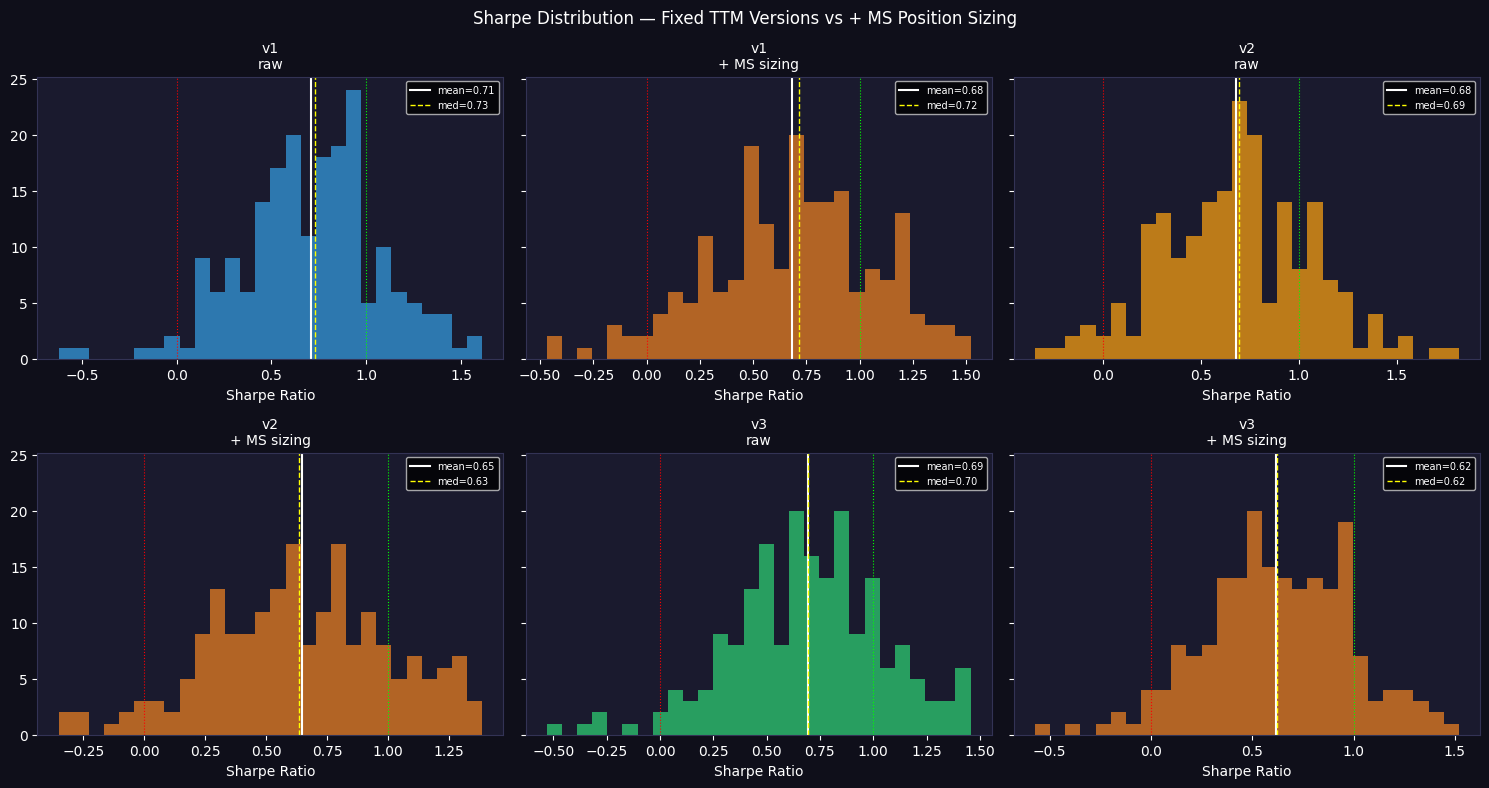

In [9]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

entries_list = []
for ver in ['v1', 'v2', 'v3']:
    entries_list.append((f'{ver}\nraw', portfolios_ttm[ver], COLORS[ver]))
    entries_list.append((f'{ver}\n+ MS sizing', portfolios_ms_size[ver], '#e67e22'))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
fig.patch.set_facecolor('#0f0f1a')
axes = axes.ravel()

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(), color='white', lw=1.5, ls='-', label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.8, ls=':')
    ax.axvline(1, color='lime', lw=0.8, ls=':')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

plt.suptitle('Sharpe Distribution — Fixed TTM Versions vs + MS Position Sizing', color='white', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Delta Sharpe vs Raw Version


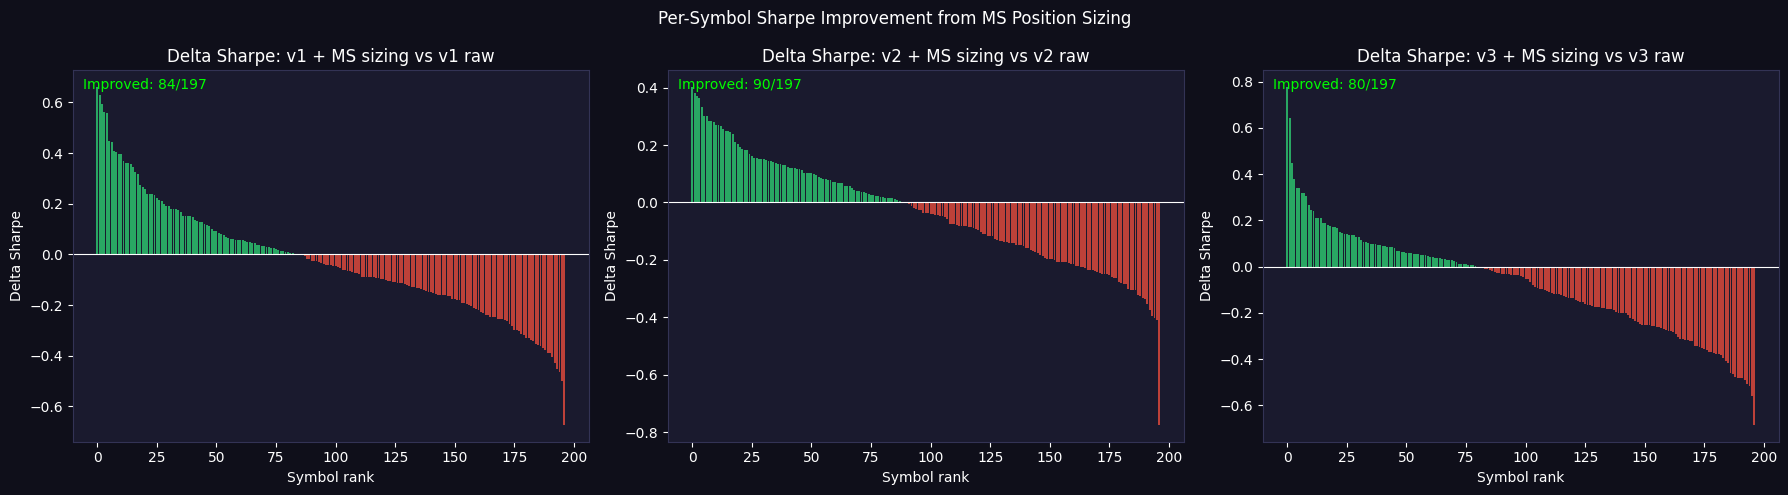

In [10]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    delta = (
        portfolios_ms_size[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
        - portfolios_ttm[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    ).dropna().sort_values(ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta]
    ax.set_facecolor('#1a1a2e')
    ax.bar(range(len(delta)), delta.values, color=colors, alpha=0.8)
    ax.axhline(0, color='white', lw=0.8)
    ax.set_title(f'Delta Sharpe: {ver} + MS sizing vs {ver} raw', color='white')
    ax.set_xlabel('Symbol rank', color='white')
    ax.set_ylabel('Delta Sharpe', color='white')
    ax.tick_params(colors='white')
    ax.text(0.02, 0.95, f'Improved: {(delta > 0).sum()}/{len(delta)}',
            transform=ax.transAxes, color='lime', fontsize=10)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333355')

plt.suptitle('Per-Symbol Sharpe Improvement from MS Position Sizing', color='white', fontsize=12)
plt.tight_layout()
plt.show()


## 9. Single-Symbol — TTM Entries with MS Regime Overlay


In [11]:
VER = 'v3'
delta = (
    portfolios_ms_size[VER].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    - portfolios_ttm[VER].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
).dropna().sort_values(ascending=False)
SYMBOL = delta.index[0]
LOOKBACK_DAYS = 400

raw_entries = entry_maps[VER]['raw'][SYMBOL].values.astype(bool)
full_size_entries = entry_maps[VER]['full_size'][SYMBOL].values.astype(bool)
reduced_size_entries = entry_maps[VER]['reduced_size'][SYMBOL].values.astype(bool)
size_frac = entry_maps[VER]['size_frac'][SYMBOL].values.astype(float)
regime_prob = ms_default['regime_prob'][SYMBOL].values
high_stress = high_stress_default[SYMBOL].values.astype(bool)
switch_up = switch_up_default[SYMBOL].values.astype(bool)
switch_dn = switch_down_default[SYMBOL].values.astype(bool)

c_sym = close[SYMBOL].values
dates = close.index
n_show = min(LOOKBACK_DAYS, len(dates))
sl_ = slice(-n_show, None)
dates_s = dates[sl_]

def s(arr):
    return arr[sl_]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
price_s = s(c_sym)
high_stress_s = s(high_stress)
switch_up_s = s(switch_up)
switch_dn_s = s(switch_dn)
ymin = np.nanmin(price_s) * 0.97
ymax = np.nanmax(price_s) * 1.03
ax.fill_between(dates_s, ymin, ymax, where=~high_stress_s,
                color='#2ecc71', alpha=0.05, label='Calm regime')
ax.fill_between(dates_s, ymin, ymax, where=high_stress_s,
                color='#e74c3c', alpha=0.10, label='High-stress regime')
ax.plot(dates_s, price_s, color='white', lw=1.0, label='Close')

ax.scatter(dates_s[s(full_size_entries)], price_s[s(full_size_entries)],
           marker='^', color='#f1c40f', s=80, zorder=5, label='TTM entry (full size)')
ax.scatter(dates_s[s(reduced_size_entries)], price_s[s(reduced_size_entries)],
           marker='v', color='#e67e22', s=80, zorder=5, label='TTM entry (reduced size)')
ax.scatter(dates_s[switch_up_s], price_s[switch_up_s],
           marker='D', color='#3498db', s=45, zorder=6, label='Regime switch up')
ax.scatter(dates_s[switch_dn_s], price_s[switch_dn_s],
           marker='D', color='#e74c3c', s=45, zorder=6, label='Regime switch down')
ax.set_title(f'{SYMBOL} — {VER} raw vs + MS Position Sizing (last {n_show} bars)', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=7, ncol=4)
ax.tick_params(colors='white')
for sp in ax.spines.values():
    sp.set_edgecolor('#333355')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
prob_s = s(regime_prob)
size_frac_s = s(size_frac)
ax2.plot(dates_s, prob_s, color='#3498db', lw=1.4, label='P(high-stress)')
ax2.plot(dates_s, size_frac_s, color='#f1c40f', lw=1.4, ls='--', label='MS size fraction')
ax2.fill_between(dates_s, 0, prob_s, where=high_stress_s, color='#e74c3c', alpha=0.25)
ax2.axhline(MS_PROB_THRESHOLD, color='#95a5a6', lw=1.0, ls=':',
            label=f'prob threshold={MS_PROB_THRESHOLD:.2f}')
ax2.axhline(MS_REDUCED_SIZE, color='#e67e22', lw=1.0, ls='-.',
            label=f'reduced size={MS_REDUCED_SIZE:.2f}')
ax2.set_ylabel('Probability / Size', color='white')
ax2.set_ylim(0, 1.05)
ax2.tick_params(colors='white')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax2.spines.values():
    sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()
print(f'{SYMBOL} | {VER} raw Sharpe: {portfolios_ttm[VER].sharpe_ratio()[SYMBOL]:.3f} | {VER}+MS sizing Sharpe: {portfolios_ms_size[VER].sharpe_ratio()[SYMBOL]:.3f}')


KeyError: ('VCS',)

## 10. Save Results


In [ ]:
h5_file = '../backend/assets/backtest_results_005c.h5'

with pd.HDFStore(h5_file, mode='w') as store:
    store.put('stats_table', stats_df, format='table')
    store.put('ms_size_fraction', ms_size_frac_default, format='table')
    for ver in ['v1', 'v2', 'v3']:
        store.put(f'sharpe_raw_{ver}', portfolios_ttm[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan), format='table')
        store.put(f'sharpe_ms_size_{ver}', portfolios_ms_size[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan), format='table')
        delta = (portfolios_ms_size[ver].sharpe_ratio() - portfolios_ttm[ver].sharpe_ratio()).replace([np.inf, -np.inf], np.nan)
        store.put(f'delta_sharpe_{ver}', delta, format='table')

print(f'Saved to {h5_file}')
